# Pre-Entrega del Proyecto Integrador: Online Retail II y CLV

Este cuaderno presenta la preparación de un dataset transaccional para una entrega académica orientada a **Customer Lifetime Value (CLV)**.

Se trabajará con el dataset **Online Retail II** del UCI Machine Learning Repository, un conjunto de transacciones reales de una tienda online del Reino Unido.

El resultado esperado es una base limpia, documentada y lista para la etapa de modelado.

## Hoja de ruta

El trabajo se organiza en los siguientes pasos:

1. Describir el problema y contextualizar el dataset.
2. Cargar los datos desde la fuente oficial.
3. Revisar estructura, tipos de datos y valores faltantes.
4. Limpiar transacciones problemáticas.
5. Construir una tabla agregada a nivel cliente.
6. Definir una variable objetivo de CLV futuro.
7. Analizar distribuciones y relaciones básicas.
8. Aplicar transformaciones de preparación.
9. Separar entrenamiento y prueba respetando la cronología.
10. Entrenar un baseline de regresión.

La lógica general será: **diagnosticar → limpiar → transformar → agregar → seleccionar → dividir**.

## Hoja de ruta

El trabajo se organiza en los siguientes pasos:

1. Describir el problema y contextualizar el dataset.
2. Cargar los datos desde la fuente oficial.
3. Revisar estructura, tipos de datos y valores faltantes.
4. Limpiar transacciones problemáticas.
5. Construir una tabla agregada a nivel cliente.
6. Definir una variable objetivo de CLV futuro.
7. Analizar distribuciones y relaciones básicas.
8. Aplicar transformaciones de preparación.
9. Separar entrenamiento y prueba respetando la cronología.
10. Entrenar un baseline de regresión.

La lógica general será: **diagnosticar → limpiar → transformar → agregar → seleccionar → dividir**.

## ¿Por qué usar Online Retail II?

Online Retail II es un dataset transaccional real de dos años, compuesto por compras realizadas por clientes de una tienda online del Reino Unido.

Es una buena base para un ejercicio de CLV porque permite trabajar con una pregunta de negocio clara: cuánto valor puede generar un cliente en el futuro.

Además, el problema requiere construir la variable objetivo de forma temporal, usando una ventana de observación y una ventana futura. Esto hace que el ejercicio sea más cercano a un caso real de análisis de clientes y regresión.

En otras palabras: el dataset no solo sirve para practicar limpieza y agregación, sino también para justificar decisiones de modelado con criterio académico.

## Variables del dataset

De acuerdo con la documentación oficial del UCI, el dataset contiene estas variables principales:

- `InvoiceNo`: número de factura;
- `StockCode`: código del producto;
- `Description`: nombre del producto;
- `Quantity`: cantidad vendida;
- `InvoiceDate`: fecha y hora de la transacción;
- `UnitPrice`: precio unitario;
- `CustomerID`: identificador del cliente;
- `Country`: país de residencia del cliente.

Además, la documentación indica que hay valores faltantes y que los registros de cancelación comienzan con la letra `C` en `InvoiceNo`.

## Preparación del entorno

Vamos a importar las librerías necesarias para trabajar con datos, graficar y construir un baseline de regresión.

Si el entorno no tiene alguno de estos paquetes instalados, se puede completar la instalación desde la terminal o descomentar la línea correspondiente cuando resulte necesario.

In [ ]:
# Si hiciera falta, descomentar la siguiente línea:
# %pip install ucimlrepo -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Carga del dataset

Para esta pre-entrega se descarga el archivo oficial en formato ZIP desde el repositorio de UCI, se extrae el Excel incluido y luego se carga en un DataFrame de pandas.

Si el entorno no tuviera acceso a internet, este bloque puede adaptarse para trabajar con una copia local del archivo Excel ya descargado.

In [7]:
# Descargamos el ZIP oficial del UCI y extraemos el archivo Excel
import os
import zipfile
import tempfile
import urllib.request

zip_url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
zip_path = os.path.join(tempfile.gettempdir(), "online_retail_ii.zip")
extract_dir = os.path.join(tempfile.gettempdir(), "online_retail_ii")
os.makedirs(extract_dir, exist_ok=True)

urllib.request.urlretrieve(zip_url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

# Buscamos el Excel dentro de la carpeta extraída
excel_path = None
for root, _, files in os.walk(extract_dir):
    for file in files:
        if file.lower().endswith((".xlsx", ".xls")):
            excel_path = os.path.join(root, file)
            break
    if excel_path:
        break

if excel_path is None:
    raise FileNotFoundError("No se encontró el archivo Excel dentro del ZIP descargado.")

# Cargamos el archivo en un DataFrame
df = pd.read_excel(excel_path)

# Estandarizamos nombres por si la fuente devuelve variantes como 'Invoice', 'Price' o 'Customer ID'
df.columns = [col.strip() for col in df.columns]
rename_map = {
    "Invoice": "InvoiceNo",
    "InvoiceNo": "InvoiceNo",
    "StockCode": "StockCode",
    "Description": "Description",
    "Quantity": "Quantity",
    "InvoiceDate": "InvoiceDate",
    "Price": "UnitPrice",
    "UnitPrice": "UnitPrice",
    "Customer ID": "CustomerID",
    "CustomerID": "CustomerID",
    "Country": "Country",
}
df = df.rename(columns={col: rename_map.get(col, col) for col in df.columns})

print("Dimensiones iniciales:", df.shape)
print("Archivo cargado:", excel_path)
print("Columnas estandarizadas:", df.columns.tolist())
df.head()

Dimensiones iniciales: (525461, 8)
Archivo cargado: /var/folders/2h/zjq0qp9j6gvbdp9dtnp9ym3m0000gn/T/online_retail_ii/online_retail_II.xlsx
Columnas estandarizadas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Diagnóstico inicial

Antes de limpiar nada, conviene observar la estructura general del dataset.

En esta etapa vamos a revisar:

- cantidad de filas y columnas;
- nombres de columnas;
- tipos de datos;
- valores faltantes;
- rango temporal disponible.

In [8]:
# Convertimos la fecha a formato datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

print("Forma del dataset:")
print(df.shape)

print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes por columna:")
print(df.isnull().sum())

print("\nRango temporal del dataset:")
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

Forma del dataset:
(525461, 8)

Columnas disponibles:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Tipos de datos:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Valores faltantes por columna:
InvoiceNo           0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     107927
Country             0
dtype: int64

Rango temporal del dataset:
2009-12-01 07:45:00
2010-12-09 20:01:00


## Limpieza de transacciones

En este tipo de datos hay varios puntos a revisar antes de construir la base final:

- transacciones canceladas, identificadas porque `InvoiceNo` comienza con `C`;
- cantidades negativas o iguales a cero;
- precios unitarios iguales o menores a cero;
- clientes sin identificador;
- descripciones faltantes;
- filas duplicadas.

Primero limpiamos el nivel transaccional y luego agregamos a nivel cliente.

In [9]:
# Guardamos una copia para no perder la versión cruda
df = df.copy()

# Eliminamos filas sin fecha, cliente o descripción
df = df.dropna(subset=["InvoiceDate", "CustomerID", "Description"])

# CustomerID suele venir como número decimal cuando hay faltantes
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)

# Nos quedamos solo con facturas no canceladas
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C", na=False)]

# Quitamos cantidades y precios no válidos
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Eliminamos duplicados exactos
duplicados = df.duplicated().sum()
df = df.drop_duplicates()

# Creamos el importe de cada línea
df["LineAmount"] = df["Quantity"] * df["UnitPrice"]

print("Filas duplicadas detectadas antes de eliminar:", duplicados)
print("Forma final del nivel transaccional:", df.shape)
print("Valores faltantes luego de la limpieza:")
print(df.isnull().sum())

Filas duplicadas detectadas antes de eliminar: 6748
Forma final del nivel transaccional: (400916, 9)
Valores faltantes luego de la limpieza:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
LineAmount     0
dtype: int64


## Resumen del nivel transaccional

Con el dataset ya limpio, revisamos estadísticas básicas.

Esto nos ayuda a identificar si existen valores extremos, distribuciones muy sesgadas o magnitudes poco esperables.

In [10]:
print(df[["Quantity", "UnitPrice", "LineAmount"]].describe())

            Quantity      UnitPrice     LineAmount
count  400916.000000  400916.000000  400916.000000
mean       13.767418       3.305826      21.945330
std        97.638385      35.047719      77.758075
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       5.000000
50%         5.000000       1.950000      12.500000
75%        12.000000       3.750000      19.500000
max     19152.000000   10953.500000   15818.400000


## Definición temporal del problema

Para construir un objetivo de CLV sin fuga de información, vamos a dividir la historia en dos ventanas:

- **ventana de observación**: usaremos los primeros 9 meses para construir las variables del cliente;
- **ventana futura**: usaremos los meses restantes para medir cuánto valor genera ese cliente después.

La variable objetivo será entonces el total monetario futuro generado por cada cliente en la ventana posterior.

Esta separación temporal es clave en un problema de CLV.

In [12]:
# Definimos las ventanas temporales
fecha_inicio = df["InvoiceDate"].min().normalize()
fecha_corte = fecha_inicio + pd.DateOffset(months=9)
fecha_fin = df["InvoiceDate"].max().normalize()

print("Fecha inicial:", fecha_inicio)
print("Fecha de corte (observación):", fecha_corte)
print("Fecha final:", fecha_fin)

df_obs = df[df["InvoiceDate"] <= fecha_corte].copy()
df_future = df[df["InvoiceDate"] > fecha_corte].copy()

print("Filas en observación:", df_obs.shape[0])
print("Filas en ventana futura:", df_future.shape[0])

Fecha inicial: 2009-12-01 00:00:00
Fecha de corte (observación): 2010-09-01 00:00:00
Fecha final: 2010-12-09 00:00:00
Filas en observación: 244976
Filas en ventana futura: 155940


## Construcción del dataset a nivel cliente

Ahora vamos a agregar la información transaccional para obtener una tabla por cliente.

La lógica será:

1. primero resumir las compras por factura;
2. luego resumir las facturas por cliente;
3. finalmente unir el valor futuro para formar la variable objetivo.

Esto nos deja una base mucho más útil para modelar CLV.

In [13]:
def safe_mode(series):
    valores = series.dropna()
    if valores.empty:
        return "Unknown"
    modos = valores.mode()
    if not modos.empty:
        return modos.iloc[0]
    return valores.iloc[0]

# Agregamos primero por factura
invoice_level = (
    df_obs.groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        InvoiceDate=("InvoiceDate", "max"),
        Country=("Country", safe_mode),
        InvoiceAmount=("LineAmount", "sum"),
        InvoiceQuantity=("Quantity", "sum"),
        ProductsPerInvoice=("StockCode", "nunique")
    )
)

# Luego agregamos por cliente
customer_df = (
    invoice_level.groupby("CustomerID", as_index=False)
    .agg(
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("InvoiceAmount", "sum"),
        AvgBasketValue=("InvoiceAmount", "mean"),
        AvgBasketQuantity=("InvoiceQuantity", "mean"),
        AvgProductsPerInvoice=("ProductsPerInvoice", "mean"),
        Country=("Country", safe_mode)
    )
)

# Variables adicionales a nivel cliente
unique_products = df_obs.groupby("CustomerID")["StockCode"].nunique().rename("UniqueProducts")
avg_unit_price = df_obs.groupby("CustomerID")["UnitPrice"].mean().rename("AverageUnitPrice")

customer_df = customer_df.merge(unique_products, on="CustomerID", how="left")
customer_df = customer_df.merge(avg_unit_price, on="CustomerID", how="left")

# Métricas temporales
customer_df["RecencyDays"] = (fecha_corte - customer_df["LastPurchase"]).dt.days
customer_df["TenureDays"] = (customer_df["LastPurchase"] - customer_df["FirstPurchase"]).dt.days + 1

# Variable objetivo: valor futuro generado por el cliente en la ventana posterior
target_df = (
    df_future.groupby("CustomerID", as_index=False)["LineAmount"]
    .sum()
    .rename(columns={"LineAmount": "Future_CLV"})
)

customer_df = customer_df.merge(target_df, on="CustomerID", how="left")
customer_df["Future_CLV"] = customer_df["Future_CLV"].fillna(0)
customer_df["Country"] = customer_df["Country"].fillna("Unknown")

print("Forma final del dataset a nivel cliente:", customer_df.shape)
customer_df.head()

Forma final del dataset a nivel cliente: (3321, 14)


,CustomerID,FirstPurchase,LastPurchase,Frequency,Monetary,AvgBasketValue,AvgBasketQuantity,AvgProductsPerInvoice,Country,UniqueProducts,AverageUnitPrice,RecencyDays,TenureDays,Future_CLV
0,12346,2009-12-14 08:34:00,2010-06-28 13:53:00,11,372.86,33.896364,6.363636,3.0,United Kingdom,26,6.253333,64,197,0.00
1,12349,2010-04-29 13:20:00,2010-05-18 09:57:00,2,1268.52,634.260000,237.000000,23.5,Italy,47,8.395319,105,19,1402.62
2,12355,2010-05-21 11:59:00,2010-05-21 11:59:00,1,488.21,488.210000,303.000000,22.0,Bahrain,22,2.399091,102,1,0.00
3,12358,2009-12-08 07:59:00,2010-06-07 12:28:00,2,1697.93,848.965000,295.000000,17.0,Austria,34,3.442571,85,182,1021.08
4,12359,2009-12-05 13:32:00,2010-06-22 10:24:00,5,2012.03,402.406000,175.400000,17.2,Cyprus,82,5.170349,70,199,551.33


## Diagnóstico del dataset de clientes

Una vez construido el dataset final, revisamos nuevamente la calidad de los datos.

Ahora nos interesa verificar que no queden valores faltantes, duplicados ni columnas mal construidas.

In [15]:
print("Valores faltantes en customer_df:")
print(customer_df.isnull().sum())

print("\nFilas duplicadas en customer_df:")
print(customer_df.duplicated().sum())

print("\nResumen estadístico:")
print(customer_df[["Frequency", "Monetary", "AvgBasketValue", "AvgBasketQuantity", "UniqueProducts", "AverageUnitPrice", "RecencyDays", "TenureDays", "Future_CLV"]].describe())

Valores faltantes en customer_df:
CustomerID               0
FirstPurchase            0
LastPurchase             0
Frequency                0
Monetary                 0
AvgBasketValue           0
AvgBasketQuantity        0
AvgProductsPerInvoice    0
Country                  0
UniqueProducts           0
AverageUnitPrice         0
RecencyDays              0
TenureDays               0
Future_CLV               0
dtype: int64

Filas duplicadas en customer_df:
0

Resumen estadístico:
         Frequency       Monetary  AvgBasketValue  AvgBasketQuantity  \
count  3321.000000    3321.000000     3321.000000        3321.000000   
mean      3.621801    1643.779401      368.529297         240.314331   
std       6.078725    7176.620042      462.691993         967.541277   
min       1.000000       2.950000        2.950000           1.000000   
25%       1.000000     266.810000      170.170000          83.000000   
50%       2.000000     591.870000      284.288235         147.000000   
75%       4.0

## Distribución del CLV futuro

Antes de modelar, conviene observar cómo se distribuye la variable objetivo.

Si la distribución está muy sesgada, eso puede influir en la selección de transformaciones y en la interpretación del error del modelo.

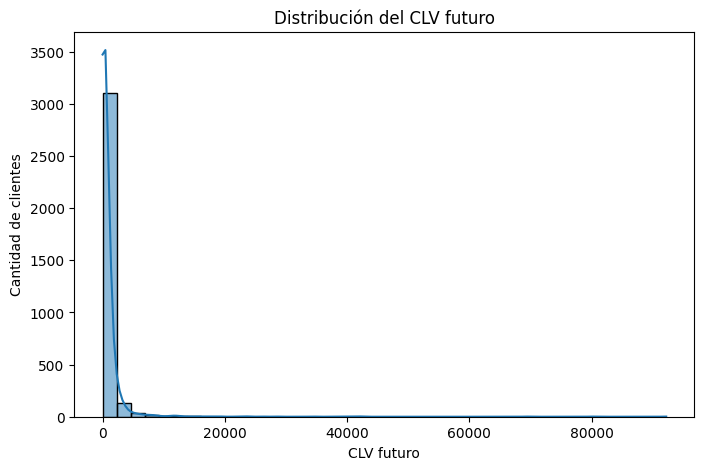

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(customer_df["Future_CLV"], bins=40, kde=True)
plt.title("Distribución del CLV futuro")
plt.xlabel("CLV futuro")
plt.ylabel("Cantidad de clientes")
plt.show()

## Relación entre variables y CLV

Vamos a revisar algunas relaciones útiles para interpretar el dataset:

- frecuencia de compra vs. CLV futuro;
- gasto acumulado vs. CLV futuro;
- recencia vs. CLV futuro.

No buscamos causalidad, sino señales que puedan ser útiles para el modelo.

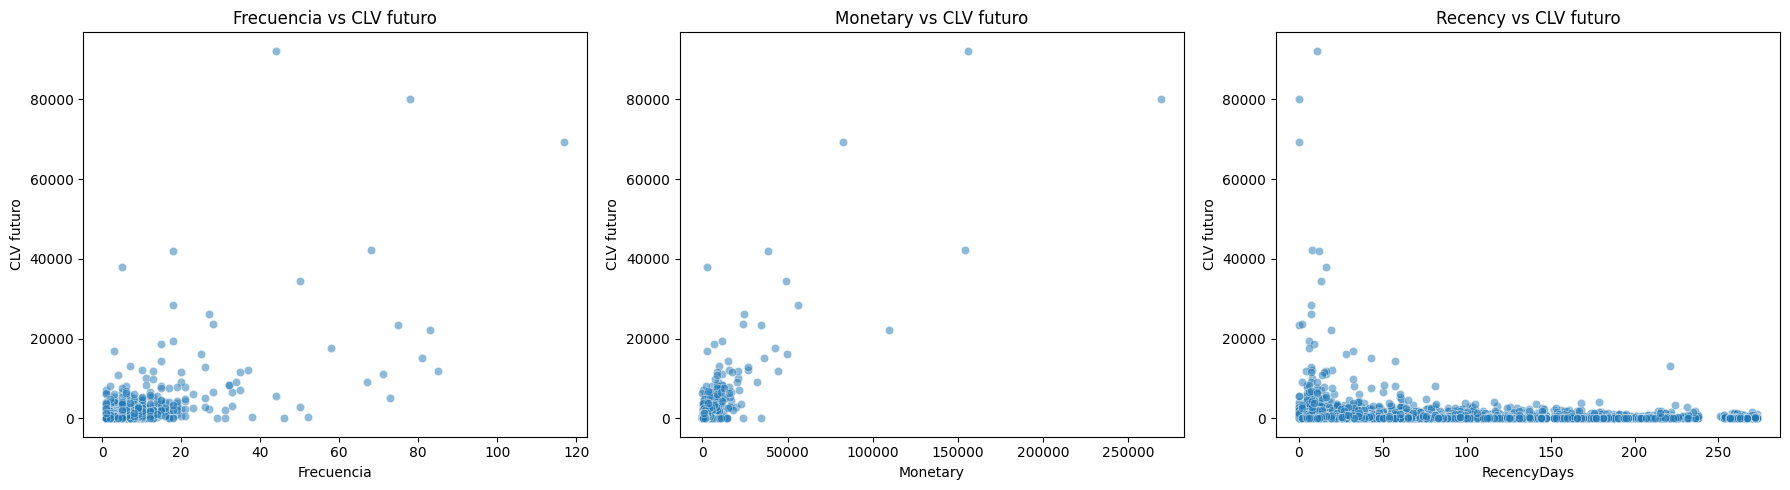

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=customer_df, x="Frequency", y="Future_CLV", alpha=0.5, ax=axes[0])
axes[0].set_title("Frecuencia vs CLV futuro")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("CLV futuro")

sns.scatterplot(data=customer_df, x="Monetary", y="Future_CLV", alpha=0.5, ax=axes[1])
axes[1].set_title("Monetary vs CLV futuro")
axes[1].set_xlabel("Monetary")
axes[1].set_ylabel("CLV futuro")

sns.scatterplot(data=customer_df, x="RecencyDays", y="Future_CLV", alpha=0.5, ax=axes[2])
axes[2].set_title("Recency vs CLV futuro")
axes[2].set_xlabel("RecencyDays")
axes[2].set_ylabel("CLV futuro")

plt.tight_layout()
plt.show()

## Matriz de correlación

La correlación entre variables numéricas nos ayuda a entender qué características están más asociadas con el CLV futuro.

Esto no reemplaza al modelado, pero sí ayuda a detectar variables útiles y relaciones redundantes.

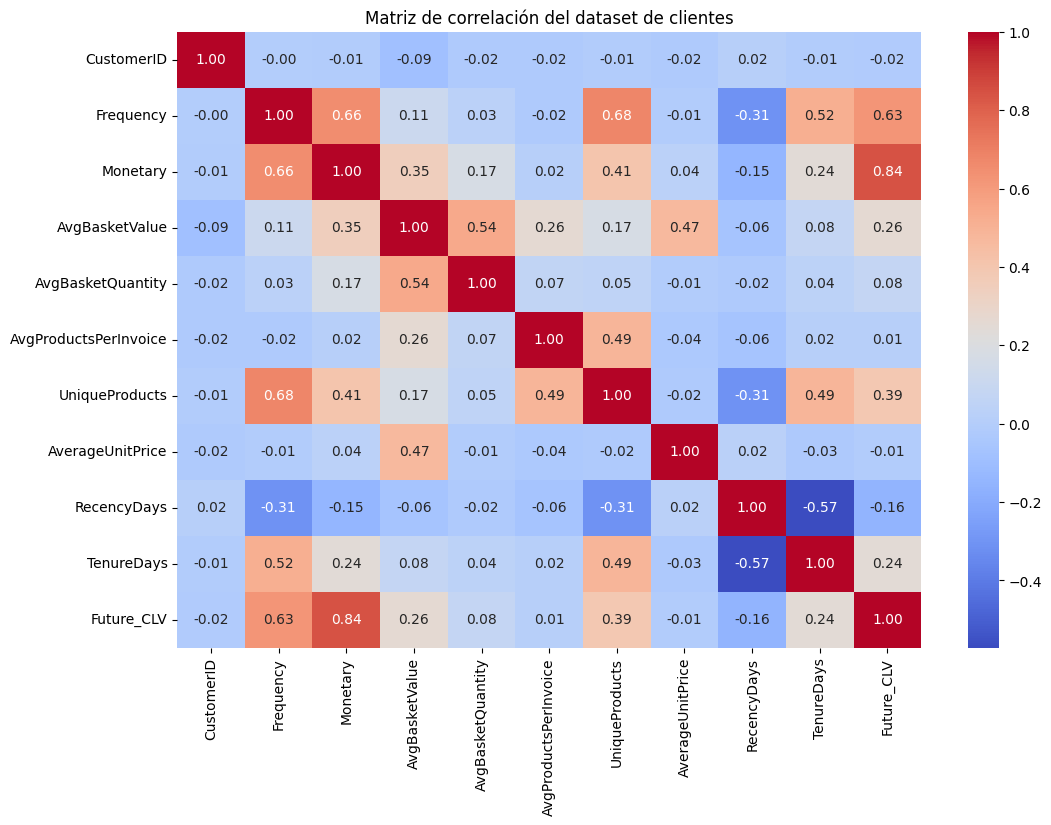

In [18]:
columnas_numericas = customer_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
matriz_correlacion = customer_df[columnas_numericas].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación del dataset de clientes")
plt.show()

## Transformaciones básicas

Al trabajar con valores monetarios suele aparecer una distribución fuertemente sesgada.

Para preparar el dataset de forma más estable, vamos a aplicar transformaciones `log1p` a algunas variables numéricas con cola larga.

Después, usaremos escalado y codificación para dejar las variables listas para un modelo de regresión.

In [19]:
# Creamos versiones logarítmicas de variables sesgadas
for columna in ["Frequency", "Monetary", "AvgBasketValue", "AvgBasketQuantity", "UniqueProducts", "AverageUnitPrice"]:
    customer_df[f"{columna}_log"] = np.log1p(customer_df[columna])

customer_df[["Frequency", "Frequency_log", "Monetary", "Monetary_log", "Future_CLV"]].head()

,Frequency,Frequency_log,Monetary,Monetary_log,Future_CLV
0,11,2.484907,372.86,5.923881,0.00
1,2,1.098612,1268.52,7.146394,1402.62
2,1,0.693147,488.21,6.192792,0.00
3,2,1.098612,1697.93,7.437754,1021.08
4,5,1.791759,2012.03,7.607396,551.33


## Selección de variables predictoras

No siempre conviene usar todas las columnas.

En esta entrega vamos a quedarnos con variables fáciles de justificar y razonables para un primer modelo:

- `Country`;
- `RecencyDays`;
- `TenureDays`;
- versiones logarítmicas de frecuencia, monetario y tamaño de la cesta;
- `UniqueProducts_log`;
- `AverageUnitPrice_log`.

La variable objetivo será `Future_CLV`.

In [20]:
# Ordenamos por fecha de primera compra para respetar la cronología
customer_sorted = customer_df.sort_values("FirstPurchase").reset_index(drop=True)

selected_features = [
    "Country",
    "RecencyDays",
    "TenureDays",
    "Frequency_log",
    "Monetary_log",
    "AvgBasketValue_log",
    "AvgBasketQuantity_log",
    "UniqueProducts_log",
    "AverageUnitPrice_log"
]

X = customer_sorted[selected_features].copy()
y = customer_sorted["Future_CLV"].copy()

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("\nColumnas numéricas predictoras:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nColumnas categóricas predictoras:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Forma de X: (3321, 9)
Forma de y: (3321,)

Columnas numéricas predictoras:
['RecencyDays', 'TenureDays', 'Frequency_log', 'Monetary_log', 'AvgBasketValue_log', 'AvgBasketQuantity_log', 'UniqueProducts_log', 'AverageUnitPrice_log']

Columnas categóricas predictoras:
['Country']


## Preprocesamiento

Vamos a preparar dos transformaciones distintas:

- las variables numéricas se imputarán con la mediana y luego se escalarán con `MinMaxScaler`;
- la variable categórica `Country` se imputará con la moda y luego se codificará con `OneHotEncoder`.

Este tipo de preprocesamiento es el que luego se reutilizará en la etapa de modelado.

In [21]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

Variables numéricas: ['RecencyDays', 'TenureDays', 'Frequency_log', 'Monetary_log', 'AvgBasketValue_log', 'AvgBasketQuantity_log', 'UniqueProducts_log', 'AverageUnitPrice_log']
Variables categóricas: ['Country']


## División temporal en entrenamiento y prueba

Aunque es tentador mezclar todo al azar, en este problema queremos respetar la cronología.

Por eso vamos a hacer una división 80/20 sobre los clientes ordenados por su primera compra observada.

Así el conjunto de prueba queda formado por clientes más tardíos, evitando usar información futura durante el entrenamiento.

In [22]:
split_idx = int(len(customer_sorted) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

print("\nRango temporal de entrenamiento:")
print(customer_sorted.iloc[:split_idx]["FirstPurchase"].min())
print(customer_sorted.iloc[:split_idx]["FirstPurchase"].max())

print("\nRango temporal de prueba:")
print(customer_sorted.iloc[split_idx:]["FirstPurchase"].min())
print(customer_sorted.iloc[split_idx:]["FirstPurchase"].max())

Dimensiones de X_train: (2656, 9)
Dimensiones de X_test: (665, 9)
Dimensiones de y_train: (2656,)
Dimensiones de y_test: (665,)

Rango temporal de entrenamiento:
2009-12-01 07:45:00
2010-05-25 12:01:00

Rango temporal de prueba:
2010-05-25 12:13:00
2010-08-31 17:31:00


## Aplicación del preprocesamiento

Ahora ajustamos el preprocesador con el conjunto de entrenamiento y lo aplicamos también al conjunto de prueba.

Esto evita que el conjunto de prueba influya en las transformaciones aprendidas.

In [23]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Forma de X_train_prepared:", X_train_prepared.shape)
print("Forma de X_test_prepared:", X_test_prepared.shape)

Forma de X_train_prepared: (2656, 37)
Forma de X_test_prepared: (665, 37)


## Baseline de regresión

Para cerrar la pre-entrega vamos a entrenar un modelo base.

Usaremos un `RandomForestRegressor`, que sirve como referencia sólida para datos tabulares y relaciones no lineales.

El objetivo no es optimizar al máximo, sino confirmar que el pipeline completo funciona de punta a punta.

In [24]:
baseline_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train_prepared, y_train)
y_pred = baseline_model.predict(X_test_prepared)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

resultado = pd.DataFrame({
    "Real": y_test.values[:10],
    "Predicho": y_pred[:10]
})
resultado

RMSE: 990.8381202982574
MAE: 421.9941270676692
R2: 0.07846741233727905


,Real,Predicho
0,54.08,542.878300
1,0.00,54.646233
2,0.00,262.340733
3,0.00,353.955333
4,773.16,170.612633
5,0.00,796.121200
6,876.41,676.873803
7,148.10,388.340300
8,602.30,201.787600
9,413.07,108.666067


## Checklist final

En este cuaderno se completaron los pasos principales de la pre-entrega:

- se seleccionó un dataset transaccional real con un objetivo de negocio claro;
- se revisó la estructura general y la calidad de los datos;
- se limpiaron cancelaciones, registros inválidos y duplicados;
- se construyeron variables agregadas a nivel cliente;
- se definió una variable objetivo de CLV futuro sin fuga de información;
- se analizaron distribuciones, correlaciones y relaciones iniciales;
- se aplicaron transformaciones básicas de preparación;
- se separaron los datos en entrenamiento y prueba respetando la cronología;
- se entrenó un baseline de regresión para validar el pipeline.

Con esto, la base queda preparada para avanzar a la etapa de modelado y comparación de alternativas.

## Cierre

La pre-entrega no busca obtener todavía el mejor modelo posible, sino demostrar una comprensión correcta del problema y una preparación rigurosa del dataset.

En un ejercicio de CLV, la calidad de la construcción temporal y de la agregación por cliente suele ser más importante que la complejidad inicial del algoritmo.

A partir de esta base, el siguiente paso consiste en probar modelos adicionales, comparar métricas y seleccionar la alternativa más adecuada para el caso de negocio.